In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# What does the CSV contain

In [10]:
df = pd.read_csv("/Users/brandonsmith/Data-515-folder/DATA-515-Final-Project/data/startup_founder_burnout_2026.csv")

In [15]:
print(f'Shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicates : {df.duplicated().sum()}')

print(f'\nNumeric columns : {len(df.select_dtypes(include=["number"]).columns)}')
print(f'\nCategorical columns : {len(df.select_dtypes(exclude=["number"]).columns)}')

Shape : 50,000 rows x 29 columns
Missing values : 0
Duplicates : 0

Numeric columns : 21

Categorical columns : 8


## Analysis of Basic Commands

We can see that the dataset is 50,000 rows by 29 columns. There are no missing values or duplicates meaning that we do not have to do any data cleaning. Looking deeper into the column specifics we can see that 21 of the 29 columns contain numeric values and the remaining 8 values are categorical columns. 

# Feature Variables

We want to create three main variables
* Shutdown Probability - A number between 0 and 1 that represents how close a startup is to shutting down. We will think of this variable as a risk meter.
* Shutdown Risk - A number between 0 and 1 as well, but it will be bucketed into three different tiers (Low, Medium, High). This makes it more readable rather looking at the raw number. 
* Startup Failure Flag - This is a binary situation (yes or no). If the startup failed that is a 1 (yes), 0 means no. This is the most straightforward thing we're trying to do when trying to predict. 

In [21]:
print(f'Shutdown Probability mean={df["Shutdown_Probability"].mean():.4f}, std={df["Shutdown_Probability"].std():.4f}')
print(f'Shutdown Risk distribution: {df["Shutdown_Risk"].value_counts().to_dict()}')
print(f'Startup Failure Flag failure rate: {df["Startup_Failure_Flag"].mean()*100:.1f}%')

Shutdown Probability mean=0.3862, std=0.2962
Shutdown Risk distribution: {'Low': 26466, 'High': 11867, 'Medium': 11667}
Startup Failure Flag failure rate: 23.7%


# What Makes a Founder?

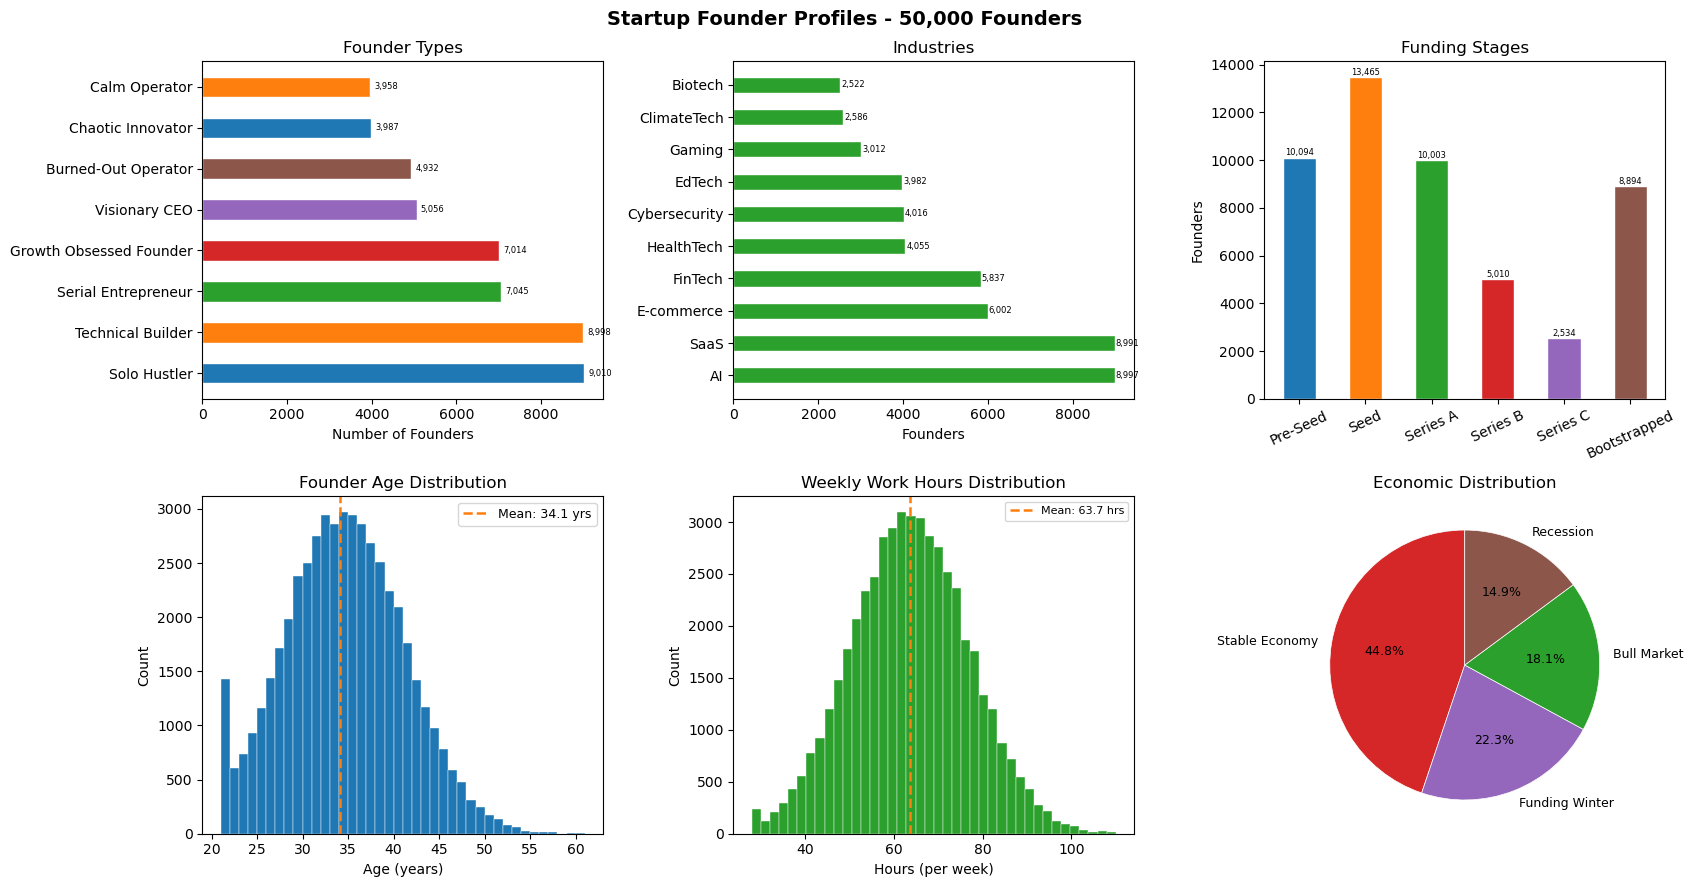

In [32]:
fig, axes = plt.subplots(2,3, figsize=(17,9))
fig.suptitle('Startup Founder Profiles - 50,000 Founders', fontsize = 14, fontweight = 'bold')

# Founder type distribution
ft = df['Founder_Type'].value_counts()
FT_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
axes[0,0].barh(ft.index,ft.values, color=FT_COLORS, edgecolor='white', height=0.5)
for i, (t,v) in enumerate(zip(ft.index,ft.values)):
    axes[0,0].text(v+100, i, f'{v:,}', va = 'center', fontsize = 6)
axes[0,0].set_title('Founder Types')
axes[0,0].set_xlabel('Number of Founders')

# Industry
ind = df['Industry'].value_counts()
axes[0,1].barh(ind.index,ind.values, color = '#2ca02c', edgecolor='white', height=0.5)
for i, (t,v) in enumerate(zip(ind.index,ind.values)):
    axes[0,1].text(v+20, i, f'{v:,}', va = 'center', fontsize = 6)
axes[0,1].set_title('Industries')
axes[0,1].set_xlabel('Founders')

# Funding stage
Stage_Order = ['Pre-Seed','Seed','Series A','Series B','Series C','Bootstrapped']
Stage_Colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
fs = df['Funding_Stage'].value_counts().reindex(Stage_Order)
axes[0,2].bar(fs.index, fs.values, color=Stage_Colors, edgecolor='white', width=0.5)
axes[0,2].tick_params(axis='x', rotation=25)
for i, (s,v) in enumerate(fs.items()):
    axes[0,2].text(i, v+100, f'{v:,}', ha='center', fontsize=6)
axes[0,2].set_title('Funding Stages')
axes[0,2].set_ylabel('Founders')

# Founder age
axes[1,0].hist(df['Founder_Age'], bins = 40, color = '#1f77b4', edgecolor='white', linewidth=0.3)
axes[1,0].axvline(df['Founder_Age'].mean(), color = '#ff7f0e', linestyle = '--', linewidth = 1.8,
                  label = f'Mean: {df["Founder_Age"].mean():.1f} yrs')
axes[1,0].set_title('Founder Age Distribution')
axes[1,0].set_xlabel('Age (years)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend(fontsize = 9)

# Work hours distribution
axes[1,1].hist(df['Weekly_Work_Hours'], bins = 40, color = '#2ca02c', edgecolor='white', linewidth=0.3)
axes[1,1].axvline(df['Weekly_Work_Hours'].mean(), color = '#ff7f0e', linestyle = '--', linewidth = 1.8,
                  label = f'Mean: {df["Weekly_Work_Hours"].mean():.1f} hrs')
axes[1,1].set_title('Weekly Work Hours Distribution')
axes[1,1].set_xlabel('Hours (per week)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(fontsize = 8)

# Economic climate
CLIMATE_PAL = {'Bull Market' : '#2ca02c', 'Stable Economy' : '#d62728', 'Funding Winter' : '#9467bd', 'Recession' : '#8c564b'}
ec = df['Economic_Climate'].value_counts()
axes[1,2].pie(ec.values, labels=ec.index,
              colors=[CLIMATE_PAL.get(k, '#7f7f7f') for k in ec.index],
              autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 0.5},
              textprops={'fontsize': 9})
axes[1,2].set_title('Economic Distribution')

plt.tight_layout()
plt.show()